In [17]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, gamma, lognorm, weibull_min, gaussian_kde, skew, genpareto
from matplotlib.ticker import FuncFormatter
import os

In [18]:
os.chdir('/home/anna/Desktop/Eco_geno_C_figures/higher_completion_bins/61')
as_all = pd.read_excel('Biome Synbio Top Match EC Comparison.xlsx')
as_all = as_all[as_all['Percentage'] > 0]
as_lost = pd.read_excel('Lost_Functions.xlsx')
as_present = pd.read_excel('Only Present Enzyme Biome Synbio Top Match EC Comparison.xlsx')
added_EC = as_all[(as_all['Synbio Presence/Absence'] == 1) & (as_all['Top Match Presence/Absence'] == 0)]

In [19]:
# as_lost
print((as_lost[(as_lost['Percentage'] <= 80)]).shape)

(26, 5)


In [12]:
print((added_EC[(added_EC['Percentage'] <= 5)]))

      EC Number  Percentage  \
1624    5.1.2.1    4.661326   
1655  2.1.1.195    4.369993   
1663   2.7.8.39    4.297160   
1684   1.2.1.59    4.151493   
1703   4.1.2.43    4.005827   
...         ...         ...   
3459  2.7.1.237    0.072833   
3476   2.1.1.86    0.072833   
3588   1.2.1.90    0.072833   
3598  2.1.1.216    0.072833   
3611   6.3.2.36    0.072833   

                                                   Name  \
1624                                  lactate racemase.   
1655      cobalt-precorrin-5B (C(1))-methyltransferase.   
1663            archaetidylinositol phosphate synthase.   
1684  glyceraldehyde-3-phosphate dehydrogenase (NAD(...   
1703                   3-hexulose-6-phosphate synthase.   
...                                                 ...   
3459                GTP-dependent dephospho-CoA kinase.   
3476                        Transferred entry: 7.2.1.4.   
3588  glyceraldehyde-3-phosphate dehydrogenase [NAD(...   
3598       tRNA (guanine(26)-N(2))-di

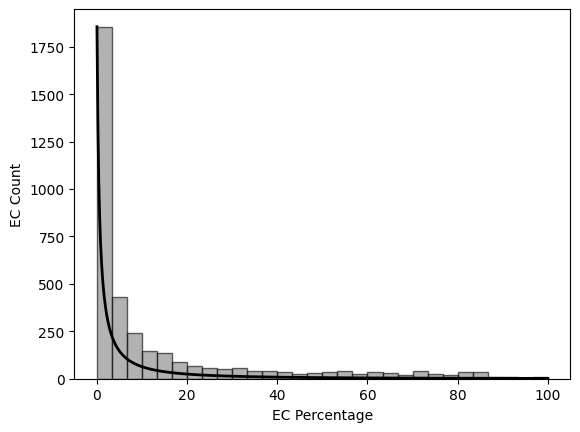

In [5]:
data = np.array(as_all['Percentage'])
counts, bins, _ = plt.hist(data, bins=30, alpha=0.6, color = 'grey', edgecolor = 'black')
# Fit a lognormal distribution to the data
shape, loc, scale = lognorm.fit(data, floc=0)
# Generate points on the x-axis
x = np.linspace(min(data), max(data), 1000)
# Calculate the lognormal PDF
pdf = lognorm.pdf(x, shape, loc, scale)
# Scale the PDF to match the histogram
pdf_scaled = pdf * (counts.max() / pdf.max())
# Plot the scaled lognormal PDF
plt.plot(x, pdf_scaled, 'black', lw=2)
plt.xlabel('EC Percentage')
plt.ylabel('EC Count')
plt.show()


/home/anna/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/anna/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(0, 0.5, 'EC Count')

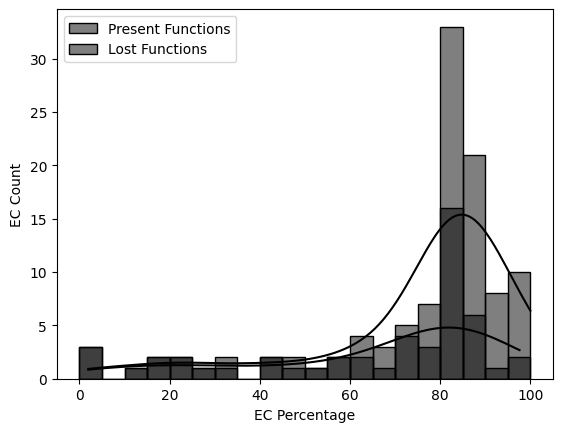

In [6]:

bin_edges = range(0, 101, 5)  # Example: bins from 0 to 100 with a step of 5

sns.histplot(x='Percentage', bins = bin_edges, data = as_present, color='black', label = 'Present Functions', kde = True, alpha = 0.5)
sns.histplot(x='Percentage',bins=bin_edges, data = as_lost, color = 'black', label='Lost Functions', kde= True, alpha = 0.5)


plt.legend()
plt.xlabel('EC Percentage')
plt.ylabel('EC Count')

/home/anna/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/anna/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(0, 0.5, 'EC Count')

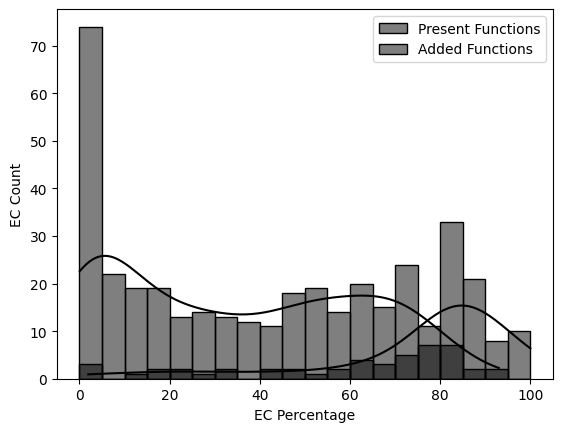

In [7]:
sns.histplot(x='Percentage', bins = bin_edges, data = as_present, color='black', label = 'Present Functions', kde = True, alpha = 0.5)
sns.histplot(x='Percentage',bins=bin_edges, data = added_EC, color = 'black', label='Added Functions', kde= True, alpha = 0.5)
plt.legend()
plt.xlabel('EC Percentage')
plt.ylabel('EC Count')